## 01. 비지도 학습과 군집화

### 01-01. 비지도 학습이란?

- 비지도 학습은 정답 `y` 없이 feature `X`만 보고 데이터 안의 구조를 찾는 학습 방식이다.

- 지도학습처럼 `이 입력의 정답은 무엇인가?`를 맞히는 것이 아니라, `데이터 안에 어떤 패턴이나 묶음이 있는가?`를 찾는 데 초점을 맞추고 있다.

```
예를 들어 고객 데이터에 구매 금액, 방문 횟수, 최근 구매일 같은 feature만 있고 고객 등급 정답이 없다고 해보자.
이때 비지도 학습은 고객들을 비슷한 행동 패턴끼리 나누거나, 전체 데이터가 어떤 구조로 퍼져 있는지 확인하는 데 사용할 수 있음.
```

비지도 학습에서 자주 다루는 작업은 다음과 같음.

- **군집화**: 비슷한 데이터끼리 그룹으로 묶음.
- **차원축소**: 많은 feature를 적은 축으로 줄여 구조를 보기 쉽게 만듦.
- **이상치 탐지**: 대부분의 데이터와 다른 특이한 데이터를 찾음.

---

### 01-02. 군집화란?

- 군집화는 비슷한 데이터끼리 같은 그룹으로 묶는 비지도 학습 방법이다.

- 여기서 그룹을 **cluster**, 군집이라고 부른다.

- 중요한 점은 **군집 번호가 정답 class가 아니라는 것**이다.

```
예를 들어 KMeans가 어떤 데이터를 `cluster 0`, `cluster 1`, `cluster 2`로 나누더라도, 이 번호는 모델이 붙인 임의의 그룹 이름표이다.
`0번이 더 좋다`, `1번이 더 높은 등급이다` 같은 의미는 자동으로 생기지 않는다.
```

**군집화 결과는 사람이 다시 해석해야 의미가 생긴다.**

```
예를 들어 고객 데이터를 군집화한 뒤 각 군집의 평균 구매 금액, 방문 횟수, 최근 구매일을 비교해서
`VIP 고객`, `신규 고객`, `이탈 위험 고객`처럼 이름을 붙일 수 있음.
```

**군집화는 어디에 쓰는가?**
- 고객을 비슷한 구매 패턴끼리 나누는 고객 세분화.
- 이미지나 문서를 비슷한 특징끼리 묶는 탐색 작업.
- 이상치 탐지 전 정상 그룹과 다른 그룹을 찾는 사전 분석.

---

### 01-03. 이미지로 보는 군집화 알고리즘의 차이

아래 이미지는 여러 군집화 알고리즘이 다양한 모양의 데이터에서 어떻게 다르게 동작하는지 보여줌.

https://scikit-learn.org/1.5/modules/clustering.html

![](https://scikit-learn.org/1.5/_images/sphx_glr_plot_cluster_comparison_001.png)

- 같은 데이터라도 알고리즘에 따라 군집 결과가 달라질 수 있음.
- KMeans는 중심점과 거리를 기준으로 묶기 때문에 둥글거나 비슷한 크기의 군집에 비교적 잘 맞음.
- 반달 모양처럼 휘어진 군집이나 밀도가 다른 군집에서는 KMeans 결과가 어색할 수 있음.


## 02. KMeans

### 02-01. KMeans란?

- KMeans는 군집화 알고리즘 중 하나로, 데이터를 `k`개의 군집으로 나누는 방법이다.

- 정답 class를 맞히는 분류 모델이 아니라, feature 값이 서로 가까운 데이터끼리 묶는 비지도 학습 모델이다.

KMeans라는 이름은 다음 의미를 가진다.

- **K**: 만들 군집의 개수. 예를 들어 `k=3`이면 데이터를 3개 군집으로 나눔.
- **Means**: 각 군집의 평균 위치. 이 평균 위치를 **centroid**, 중심점이라고 부름.

KMeans의 동작 흐름은 다음과 같다.

1. 사람이 먼저 군집 개수 `k`를 정한다.
2. 모델이 각 군집을 대표할 중심점 `centroid`를 잡는다.
3. 각 데이터는 가장 가까운 중심점에 배정된다.
4. 같은 군집에 배정된 데이터들의 평균 위치로 중심점을 다시 이동한다.
5. 군집 배정과 중심점 위치가 크게 바뀌지 않을 때까지 반복한다.

---

### 02-02. KMeans에서 주의할 점

- KMeans는 거리 기반 알고리즘이므로 스케일링이 중요하다.
- KMeans는 `X`만 사용하고 `y`는 사용하지 않는다.
- KMeans가 만든 `cluster 0`, `cluster 1`, `cluster 2`는 정답 이름이 아니라 임의의 군집 번호이다.
- KMeans는 `k`를 직접 정해야 하므로 Elbow Method나 Silhouette Score로 후보를 비교한다.
- 원형에 가까운 군집에는 잘 맞지만, 복잡한 모양이나 밀도가 다른 군집에는 한계가 있음.

---

### 02-03. 이미지로 보는 KMeans 반복 과정

KMeans가 중심점을 움직이며 군집을 찾아가는 과정을 보여줌.

![](https://upload.wikimedia.org/wikipedia/commons/e/ea/K-means_convergence.gif?20170530143526)

- 처음에는 K개의 중심점(centroid)을 임의 위치에 두고 시작함.
- 중심점은 보통 데이터들의 평균 위치를 나타내는 가상의 점.
- 각 데이터는 가장 가까운 중심점에 배정하여 군집을 형성함.
- 배정된 데이터들의 평균 위치로 중심점이 다시 이동함.
- 이 과정을 반복하다가 중심점과 군집 배정이 거의 바뀌지 않으면 수렴했다고 봄.
- 따라서 KMeans의 `fit()`은 한 번에 끝나는 계산이 아니라, 중심점 배정과 이동을 반복하는 과정임.


## 03. 실습 환경 준비

Iris 데이터를 사용해 KMeans를 실습


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score, silhouette_samples
from tornado import simple_httpclient


## 04. Iris 데이터 로드

KMeans는 feature만 사용해 군집을 만들기 때문에 `target`은 학습에 넣지 않음.

군집 결과가 실제 품종과 어떻게 대응되는지 보기 위해 target을 별도로 보관함.


In [10]:
iris = load_iris(as_frame=True)

kmeans_X = iris.data.copy()
iris_target = iris.target.copy()
target_names = dict(enumerate(iris.target_names))

kmeans_base_df = kmeans_X.copy()
kmeans_base_df['target'] = iris_target
kmeans_base_df['target_name'] = kmeans_base_df['target'].map(target_names)

display(kmeans_base_df.head())
print('feature shape:', kmeans_X.shape)
print('target shape:', iris_target.shape)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


feature shape: (150, 4)
target shape: (150,)


## 05. KMeans 전 스케일링

KMeans는 샘플과 중심점 사이의 거리를 계산한다. feature마다 숫자 범위가 다르면 값이 큰 feature가 거리를 지배할 수 있으므로 스케일링을 적용함.


In [11]:
kmeans_scaler = StandardScaler()
kmeans_X_scaled = kmeans_scaler.fit_transform(kmeans_X)

## 06. KMeans 기본 군집화

Iris 데이터에는 실제 품종이 3개 있으므로 예제에서는 `k=3`으로 시작함. 실무에서는 실제 정답이 없기 때문에 `k`를 여러 후보로 비교해야 함.


In [32]:
# k=3으로 설정하여 군집 결과를 확인
kmeans_model = KMeans(
    n_clusters=3, # 형성하려는 군집의 개수

    # 초기 중심점이 너무 몰리지 않도록 안정적인 시작점을 선택
    init = 'k-means++',

    # 서로 다른 초기 중심점으로 10번 실행한 뒤 가장 좋은 결과를 선택
    n_init=10,

    # 중심점 갱신을 최대 300번까지 진행
    max_iter = 300,
    random_state = 42,
)

# fit.predict(): 중심점 학습하고 예측(각 샘플이 속한 군집의 번호) 반환
cluster_labels = kmeans_model.fit_predict(kmeans_X_scaled)

cluster_result_df = kmeans_base_df.copy()
cluster_result_df['cluster'] = cluster_labels

# display(cluster_result_df.head())

# kmeans_model.cluster_centers_
# - 학습된 군집의 중심점
# - 스케일링된 좌표계 기준의 값이다.
center_df = pd.DataFrame(
    kmeans_model.cluster_centers_,
    columns= kmeans_X.columns,
)

display(center_df.round(3))

print('inertia :', round(kmeans_model.inertia_, 3))

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,0.507,-0.427,0.652,0.627
1,-1.015,0.853,-1.305,-1.255


inertia : 222.362


## 07. 실제 품종과 군집 결과 비교

Iris 데이터에는 실제 품종 target이 있으므로 학습 후 군집과 품종을 비교할 수 있음. 하지만 이것은 수업용 해석 장치이며, KMeans 자체는 target 없이 동작함.


In [18]:
    
# 한 실제 class가 하나의 cluster(군집)에 많이 모이면
# 그 class의 구조를 KMeans가 잘 잡은 것으로 볼 수 있음. (setosa)

# 여러 class가 하나의 cluster에 섞이면
# 해당 class들은 feature 공간이 서로 가깝거나
# 군집 알고리즘이 적절하지 않았다고 판단할 수 있다.

cluster,0,1,2
actual_class,,,
setosa,0,50,0
versicolor,39,0,11
virginica,14,0,36


## 08. PCA 2차원 시각화로 군집 결과 보기

KMeans는 4개 feature로 학습했지만, 사람은 4차원 공간을 직접 볼 수 없음.

그래서 PCA로 feature를 2차원으로 줄인 뒤 실제 품종과 군집 결과를 나란히 비교함.


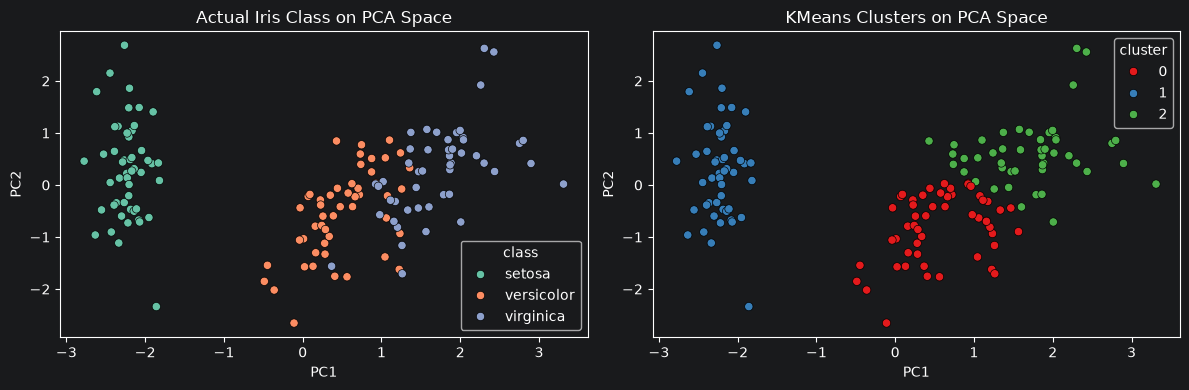

In [23]:
kmeans_pca = PCA(n_components=2)
kmeans_X_pca = kmeans_pca.fit_transform(kmeans_X_scaled)

cluster_result_df['pc1'] = kmeans_X_pca[:, 0]
cluster_result_df['pc2'] = kmeans_X_pca[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 왼쪽 그래프: 실제 품종 target 기준 색상 부여
sns.scatterplot(
    data=cluster_result_df,
    x='pc1',
    y='pc2',
    hue='target_name',
    palette='Set2',
    edgecolor='black',
    ax=axes[0],
)

axes[0].set_title('Actual Iris Class on PCA Space')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(title='class')


# 오른쪽 그래프: KMeans 만든 cluster(군집) 기준 색상 부여
sns.scatterplot(
    data=cluster_result_df,
    x='pc1',
    y='pc2',
    hue='cluster',
    palette='Set1',
    edgecolor='black',
    ax=axes[1],
)

axes[1].set_title('KMeans Clusters on PCA Space')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(title='cluster')

plt.tight_layout()
plt.show()

### 09. Elbow Method로 k 후보 비교

KMeans는 `k`, 즉 만들 군집의 개수를 사람이 먼저 정해야 한다.
그래서 여러 `k` 값을 넣어 보고, 어떤 `k`가 적절한지 비교하는 과정이 필요하다.

Elbow Method는 `inertia`를 이용해 적절한 `k` 후보를 찾는 방법이다.

### `inertia`의 의미

`inertia`는 각 샘플이 **자기 군집 중심점에서 얼마나 떨어져 있는지**를 모두 더한 값이다.  
정확히는 각 샘플과 중심점 사이 거리의 제곱합이다.

```text
inertia = 각 샘플과 자기 군집 중심점 사이 거리 제곱합
```

- `inertia`가 크면 군집 안의 데이터가 중심점에서 멀리 퍼져 있다는 뜻이다.
- `inertia`가 작으면 군집 안의 데이터가 중심점 주변에 조밀하게 모여 있다는 뜻이다.

### 왜 k가 커지면 inertia가 줄어드는가?

`k`가 커지면 중심점 개수가 많아진다.  
중심점이 많아지면 각 데이터는 더 가까운 중심점을 만날 가능성이 커진다.  
그래서 `k`를 늘릴수록 `inertia`는 거의 항상 감소한다.

하지만 `inertia`가 계속 줄어든다고 해서 `k`를 무한히 크게 잡으면 안 된다.  
예를 들어 데이터 150개를 군집 150개로 나누면 각 데이터가 거의 자기 혼자 군집이 되어 `inertia`는 매우 작아지지만, 군집화의 의미는 사라진다.

### Elbow Method 해석 방법

Elbow Method는 `inertia`가 감소하는 그래프에서 **감소 폭이 갑자기 완만해지는 지점**을 찾는다.  
그 지점을 팔꿈치처럼 꺾이는 지점이라고 해서 **Elbow**라고 부른다.

절차:
1. `k` 후보를 여러 개 정한다.
2. 각 `k`마다 KMeans 모델을 학습한다.
3. 각 모델의 `inertia`를 계산한다.
4. `k`와 `inertia` 그래프를 그린다.
5. 감소 폭이 급격히 줄어드는 지점을 `k` 후보로 본다.

주의할 점:
- Elbow Method는 정확한 정답을 알려주는 방법이 아니다.
- 그래프가 뚜렷하게 꺾이지 않으면 여러 `k`가 후보가 될 수 있다.
- `inertia`는 군집 내부 거리만 보므로, 군집끼리 잘 분리되었는지는 따로 확인해야 한다.


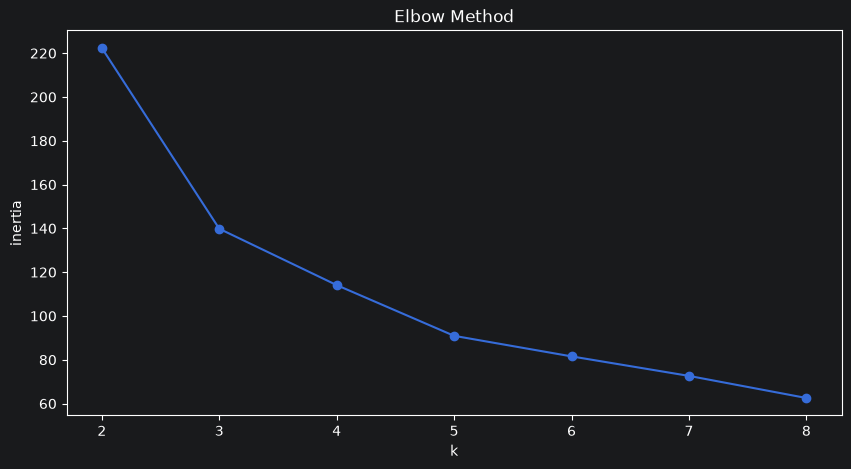

In [27]:
# k 후보를 2~8로 지정
k_values = range(2,9)

# 측정된 inertia를 저장할 리스트
inertia_results = []

for k in k_values:

    model = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )
    model.fit(kmeans_X_scaled)

    inertia_results.append({
        'k': k,
        'inertia' : model.inertia_,
    })

inertia_df = pd.DataFrame(inertia_results)


plt.figure(figsize=(10, 5))
plt.plot(inertia_df['k'], inertia_df['inertia'], marker='o')
plt.title('Elbow Method')
plt.xlabel('k')
plt.ylabel('inertia')
plt.xticks(list(k_values))
plt.show()

# Elbow method를 보는 방법
# - 경사가 완만해지는 곳이 k 후보
# - 단, 경사가 갑자기 완만해져도 이후에 inertia 값이 일정 크기로 줄어들면
# 큰 값으로 감소하는 것이 보임면 아직 군집을 더 나누는 것이 이득이라고 판별할 수 있다

## 10. Silhouette Score로 k 후보 비교

Silhouette Score는 군집이 **안쪽으로는 잘 뭉쳐 있고, 바깥쪽으로는 잘 떨어져 있는지**를 보는 지표이다.

Elbow Method가 군집 내부 거리인 `inertia`만 본다면, Silhouette Score는 다음 두 가지를 함께 본다.

1. 같은 군집 안의 데이터들과 얼마나 가까운가
2. 다른 군집의 데이터들과 얼마나 멀리 떨어져 있는가

### 실루엣 계수의 의미

각 샘플은 실루엣 계수를 하나씩 가진다.

```text
1에 가까움: 자기 군집에 잘 속해 있고, 다른 군집과도 잘 떨어져 있음
0 근처: 두 군집 사이 경계에 있어 애매함
음수: 자기 군집보다 다른 군집에 더 가까울 수 있음
```

Silhouette Score는 전체 샘플의 실루엣 계수 평균이다.

- 값이 높을수록 군집 품질이 좋다고 해석한다.
- 일반적으로 `-1`부터 `1` 사이 값을 가진다.
- 같은 데이터와 같은 알고리즘에서 여러 `k`를 비교할 때 유용하다.

### Elbow와 다른 점

- Elbow Method는 이렇게 질문한다.

```text
k를 더 늘렸을 때, 군집 내부 거리 합이 얼마나 더 줄어드는가?
```

- Silhouette Score는 이렇게 질문한다.

```text
군집 안은 충분히 가깝고, 군집끼리는 충분히 떨어져 있는가?
```

따라서 `k`를 늘려 `inertia`가 줄어들더라도, 군집끼리의 분리가 좋아지지 않으면 Silhouette Score는 낮아질 수 있다.


In [30]:
# k 후보별 평균 실루엣 점수를 비교
silhouette_results = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )
    # 현재 k로 군집을 만들고 각 샘플 데이터가 몇 번 군집에 속하는지 반환
    labels = model.fit_predict(kmeans_X_scaled)

    # 전체 샘플의 평균 실루엣 점수를 계산하여 반환
    score = silhouette_score(kmeans_X_scaled, labels)

    silhouette_results.append({
        'k': k,
        'silhouette_score': score,
    })

silhouette_df = pd.DataFrame(silhouette_results)
display(silhouette_df.round(3))

plt.figure(figsize=(10, 5))
plt.plot(
    silhouette_df['k'],
    silhouette_df['silhouette_score'],
    marker = 'o'
)

plt.title('Silhouette Score by k')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.xticks(list(k_values))
plt.show()

# silhouette score 가 높을수록 군집 내부는 가깝고, 군집끼리의 거리는 멀다!

# 점수가 가장 높다고해서 해당 k가 정답은 아니다(후보일 뿐)

# Elbow Method의 결과와 Silhouette Score 결과가 같은 k를 가리키면
# 해당 k는 더 신뢰할 수 있는 후보로 볼 수 있다.



,k,silhouette_score
0,2,0.582
1,3,0.460
2,4,0.387
3,5,0.346
4,6,0.317
5,7,0.320
6,8,0.339


## 11. Elbow와 Silhouette이 다른 k를 제안할 때

같은 데이터로 Elbow Method와 Silhouette Score를 계산했는데 서로 다른 `k`가 나올 수 있다.  
이것은 오류가 아니라, 두 방법이 보는 관점이 다르기 때문이다.

### 왜 결과가 달라질 수 있는가?

Elbow Method는 `k`를 늘렸을 때 **군집 내부 거리 합이 얼마나 줄어드는지**를 본다.  
즉, 중심점과 데이터가 가까워지는 정도를 본다.

Silhouette Score는 **군집 내부 응집도와 군집 간 분리도**를 함께 본다.  
즉, 같은 군집끼리는 가깝고 다른 군집과는 멀어야 좋은 점수를 받는다.

그래서 다음과 같은 상황이 생길 수 있다.

- `k`를 크게 하면 `inertia`는 더 줄어듦
- 하지만 원래 하나로 봐도 되는 덩어리를 억지로 쪼개면 군집 간 분리가 애매해짐
- 이 경우 Elbow는 큰 `k`를 후보로 보지만, Silhouette은 더 작은 `k`를 좋게 볼 수 있음

### Iris 예제에서의 해석

Iris 데이터는 실제 품종이 3개이다.  
하지만 feature 공간에서는 한 품종은 비교적 잘 떨어져 있고, 나머지 두 품종은 서로 겹치는 부분이 있다.

그래서 지표가 다음처럼 다르게 보일 수 있다.

- Elbow Method: `k=3` 또는 `k=5` 근처가 후보처럼 보일 수 있음
- Silhouette Score: `k=2`가 가장 높게 나올 수 있음

이때 `k=2`는 보통 다음 구조를 잘 잡은 결과로 볼 수 있다.

```text
잘 분리되는 한 덩어리 vs 서로 많이 겹치는 나머지 덩어리
```

반면 `k=3`은 실제 Iris 품종이 3개라는 도메인 정보를 반영해 해석하기 좋은 선택일 수 있다.

### 어떤 k를 선택하는 것이 좋은가?

정답은 목적에 따라 달라진다.

- 자연스럽게 잘 분리되는 큰 덩어리를 찾고 싶다면: Silhouette Score가 높은 `k`를 우선 고려한다.
- 실제 업무에서 필요한 그룹 수가 정해져 있다면: 그 그룹 수를 우선 후보로 두고 지표를 참고한다.
- 세분화된 고객군, 상품군처럼 더 자세한 분리가 필요하다면: Elbow 후보와 해석 가능성을 함께 본다.
- 군집 결과를 설명해야 한다면: 그래프와 군집별 feature 평균을 확인해 사람이 이해할 수 있는 군집인지 판단한다.

이 수업의 Iris 예제에서는 다음처럼 정리할 수 있다.

```text
지표만 보면 k=2가 가장 뚜렷하게 분리된 군집이다.
하지만 Iris 품종이 3개라는 해석 목적을 고려하면 k=3도 중요한 후보이다.
따라서 최종 k는 지표 하나로 결정하지 않고, Elbow, Silhouette, 시각화, 도메인 해석을 함께 보고 선택한다.
```


## 12. 샘플별 실루엣 계수 확인

- 평균 실루엣 점수만 보면 군집별 품질 차이를 놓칠 수 있다.
- `silhouette_samples()`를 사용하면 각 샘플의 실루엣 계수를 확인할 수 있음.


,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,53.0,0.393,0.151,0.038,0.339,0.416,0.539,0.586
1,50.0,0.636,0.106,0.078,0.595,0.665,0.701,0.734
2,47.0,0.347,0.167,-0.025,0.237,0.401,0.468,0.550


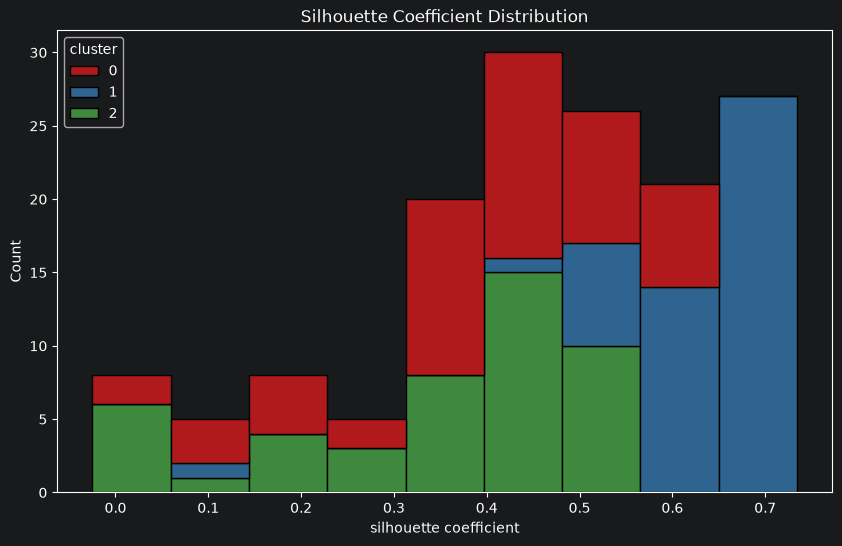

In [31]:
# silhouette_samples(): 각 샘플별 실루엣 계수를 반환함.
cluster_result_df['silhouette_coef'] = silhouette_samples(kmeans_X_scaled, cluster_labels)

# groupby(): 군집별 실루엣 계수 분포를 요약함.
silhouette_summary = cluster_result_df.groupby('cluster')['silhouette_coef'].describe()
display(silhouette_summary.round(3))

plt.figure(figsize=(10, 6))
sns.histplot(
    data=cluster_result_df,
    x='silhouette_coef',
    hue='cluster',
    multiple='stack',
    palette='Set1'
)
plt.title('Silhouette Coefficient Distribution')
plt.xlabel('silhouette coefficient')
plt.show()

## 13. 수업 마무리 정리

- KMeans는 target 없이 feature만 보고 비슷한 샘플끼리 묶는 군집화 알고리즘임.
- KMeans 학습에는 실제 class target을 넣지 않으며, target은 결과 해석용으로만 사용함.
- 거리 기반 알고리즘이므로 스케일링이 중요함.
- `k`는 사람이 정해야 하므로 Elbow Method, Silhouette Score, 시각화, 업무 해석 가능성을 함께 고려함.
- Elbow Method는 군집 내부 거리 감소 폭을 보고, Silhouette Score는 군집 내부 응집도와 군집 간 분리도를 함께 봄.
- 두 방법이 다른 `k`를 제안하면 오류가 아니라 관점 차이로 해석하고, 수업/업무 목적에 맞는 `k`를 선택함.
- 다음 DBSCAN에서는 군집 수를 미리 정하지 않고 밀도 기준으로 군집을 찾는 방법을 다룸.
